In [1]:
import numpy as np
import matplotlib.pyplot as plt

import soundfile as sf

import librosa

In [16]:
filename = r'C:\Users\kanga\Desktop\AI_study\vocal-pitch-matcher\music\FightingGoldVocal.wav'
y, sr = librosa.load(filename)

In [17]:
print(filename)
print(type(filename))

C:\Users\kanga\Desktop\AI_study\vocal-pitch-matcher\music\FightingGoldVocal.wav
<class 'str'>


In [18]:
# We'll generate 64 frames at a time, each frame having 2048 samples
# and 75% overlap.
#

n_fft = 2048
hop_length = 512

# fill_value pads out the last frame with zeros so that we have a
# full frame at the end of the signal, even if the signal doesn't
# divide evenly into full frames.
sr = librosa.get_samplerate(filename)

stream = librosa.stream(filename, block_length=16,
                        frame_length=n_fft,
                        hop_length=hop_length,
                        mono=True,
                        fill_value=0)

In [19]:
# Make an array to store the frequency-averaged PCEN values
pcen_blocks = []

# Initialize the PCEN filter delays to steady state
zi = None

# Create a handle for storing the block STFT outputs
# After the first block has been processed, we can reuse
# this buffer instead of allocating a new one for each block.
D = None

for y_block in stream:
    # Compute the STFT (without padding, so center=False)
    D = librosa.stft(y_block, n_fft=n_fft, hop_length=hop_length,
                     center=False, out=D)

    # Compute PCEN on the magnitude spectrum, using initial delays
    # returned from our previous call (if any)
    # store the final delays for use as zi in the next iteration
    P, zi = librosa.pcen(np.abs(D), sr=sr, hop_length=hop_length,
                         zi=zi, return_zf=True)

    # Compute the max PCEN over frequency, and append it to our list
    pcen_blocks.extend(np.max(P, axis=0))

# Cast to a numpy array for use downstream
pcen_blocks = np.asarray(pcen_blocks)

In [20]:
y, sr = librosa.load(filename, sr=sr)

# Keep the same parameters as before
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, center=False)

# Compute pcen on the magnitude spectrum.
# We don't need to worry about initial and final filter delays if
# we're doing everything in one go.
P = librosa.pcen(np.abs(D), sr=sr, hop_length=hop_length)

pcen_full = np.max(P, axis=0)

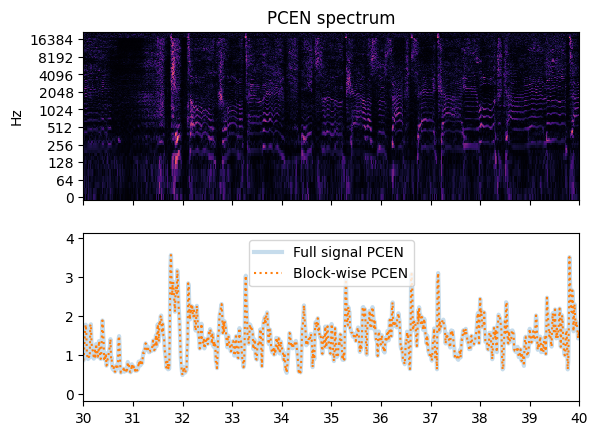

In [21]:
# First, plot the spectrum
fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.specshow(P, sr=sr, hop_length=hop_length,
                         x_axis='time', y_axis='log', ax=ax[0])
ax[0].set(title='PCEN spectrum')
ax[0].label_outer()

# Now we'll plot the pcen curves
times = librosa.times_like(pcen_full, sr=sr, hop_length=hop_length)
ax[1].plot(times, pcen_full, linewidth=3, alpha=0.25, label='Full signal PCEN')
times = librosa.times_like(pcen_blocks, sr=sr, hop_length=hop_length)
ax[1].plot(times, pcen_blocks, linestyle=':', label='Block-wise PCEN')
ax[1].legend()

# Zoom in to a short patch to see the fine details
ax[1].set(xlim=[30, 40]);